In [2]:
%pip install tensorflow

  Using cached tensorflow-2.21.0-cp312-cp312-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.5.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached protobuf-7.36.0-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.3.0-cp312-cp312-win_amd64.whl.metadata (7.6 kB)
  Using cached grpcio-1.83.1-cp312-cp312-win_amd64.whl.metadata (3.8 kB)
  Using cached keras-3.15.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached h5py-3.14.0-cp312-cp312-win_amd64.whl.metadata (2.7 kB)
  Using cached m


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import sys
import tensorflow as tf

print("Python:", sys.executable)
print("TensorFlow:", tf.__version__)

Python: c:\Users\adity\OneDrive\Desktop\resume\.venv\Scripts\python.exe
TensorFlow: 2.21.0


In [3]:
import sys
!{sys.executable} -m pip install tensorflow


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys

print("Jupyter Python:")
print(sys.executable)

!{sys.executable} -m pip install opencv-python

Jupyter Python:
c:\Users\adity\OneDrive\Desktop\resume\.venv\Scripts\python.exe
  Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python-5.0.0.93-cp37-abi3-win_amd64.whl (44.0 MB)



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import cv2

print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


In [6]:
# ============================================================
# CELL 1 - IMPORT LIBRARIES
# ============================================================

import os
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from PIL import Image

import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.5.0


In [7]:
# ============================================================
# CELL 2 - CHECK TENSORFLOW AND GPU
# ============================================================

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU detected:")
    for gpu in gpus:
        print(gpu)
else:
    print("No GPU detected. Training will use CPU.")

TensorFlow version: 2.21.0
No GPU detected. Training will use CPU.


In [8]:
# ============================================================
# CELL 3 - PROJECT PATHS
# ============================================================

BASE_DIR = r"D:\Deep Learning\Assignment 4"

RAW_DIR = os.path.join(
    BASE_DIR,
    "dataset",
    "raw"
)

PROCESSED_DIR = os.path.join(
    BASE_DIR,
    "dataset",
    "processed"
)

REDUCED_DIR = os.path.join(
    BASE_DIR,
    "dataset",
    "reduced"
)

MODEL_DIR = os.path.join(
    BASE_DIR,
    "models"
)

RESULT_DIR = os.path.join(
    BASE_DIR,
    "results"
)

for folder in [
    PROCESSED_DIR,
    REDUCED_DIR,
    MODEL_DIR,
    RESULT_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("Raw dataset:", RAW_DIR)
print("Processed dataset:", PROCESSED_DIR)
print("Reduced dataset:", REDUCED_DIR)

Raw dataset: D:\Deep Learning\Assignment 4\dataset\raw
Processed dataset: D:\Deep Learning\Assignment 4\dataset\processed
Reduced dataset: D:\Deep Learning\Assignment 4\dataset\reduced


In [9]:
import os

BASE_DIR = r"C:\Users\adity\OneDrive\Desktop\Assignment 4"
DATASET_DIR = os.path.join(BASE_DIR, "dataset")
RAW_DIR = os.path.join(DATASET_DIR, "raw")

print("BASE_DIR:", BASE_DIR)
print("DATASET_DIR:", DATASET_DIR)
print("RAW_DIR:", RAW_DIR)

print("\nBASE exists:", os.path.exists(BASE_DIR))
print("Dataset exists:", os.path.exists(DATASET_DIR))
print("Raw exists:", os.path.exists(RAW_DIR))

if os.path.exists(DATASET_DIR):
    print("\nDataset folder contains:")
    for item in os.listdir(DATASET_DIR):
        print("-", item)

BASE_DIR: C:\Users\adity\OneDrive\Desktop\Assignment 4
DATASET_DIR: C:\Users\adity\OneDrive\Desktop\Assignment 4\dataset
RAW_DIR: C:\Users\adity\OneDrive\Desktop\Assignment 4\dataset\raw

BASE exists: True
Dataset exists: True
Raw exists: True

Dataset folder contains:
- processed
- raw
- reduced


In [10]:
# ============================================================
# CELL 5 - COUNT IMAGES PER STUDENT
# ============================================================

image_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

class_counts = {}

for student in classes:

    folder = os.path.join(
        RAW_DIR,
        student
    )

    count = sum(
        1
        for file in os.listdir(folder)
        if file.lower().endswith(image_extensions)
    )

    class_counts[student] = count

count_df = pd.DataFrame(
    list(class_counts.items()),
    columns=["Student", "Images"]
)

print(count_df)

print("\nTotal images:", count_df["Images"].sum())

               Student  Images
0       Angelina Jolie     100
1            Brad Pitt     100
2    Denzel Washington     100
3         Hugh Jackman     100
4    Jennifer Lawrence     100
5          Johnny Depp     100
6         Kate Winslet     100
7    Leonardo DiCaprio     100
8            Megan Fox     100
9      Natalie Portman     100
10       Nicole Kidman     100
11    Robert Downey Jr     100
12      Sandra Bullock     100
13  Scarlett Johansson     200
14          Tom Cruise     100
15           Tom Hanks     100
16          Will Smith     100

Total images: 1800


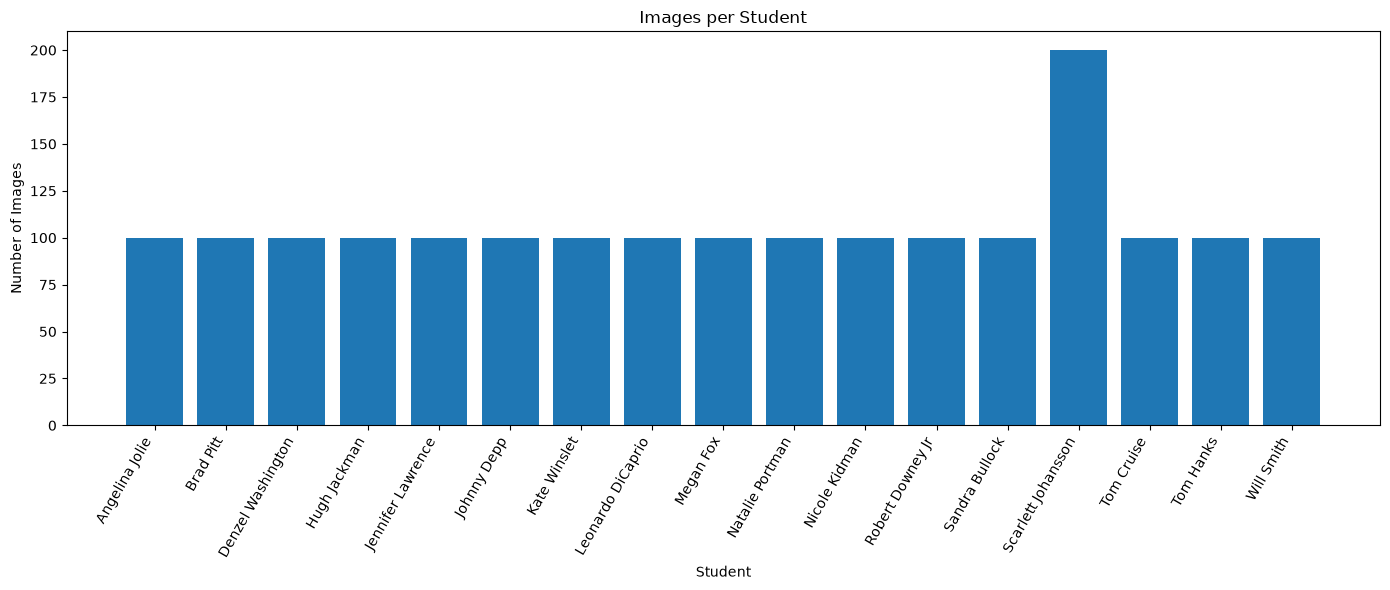

In [11]:
# ============================================================
# CELL 6 - DATASET DISTRIBUTION
# ============================================================

plt.figure(figsize=(14, 6))

plt.bar(
    count_df["Student"],
    count_df["Images"]
)

plt.xlabel("Student")
plt.ylabel("Number of Images")
plt.title("Images per Student")

plt.xticks(
    rotation=60,
    ha="right"
)

plt.tight_layout()
plt.show()

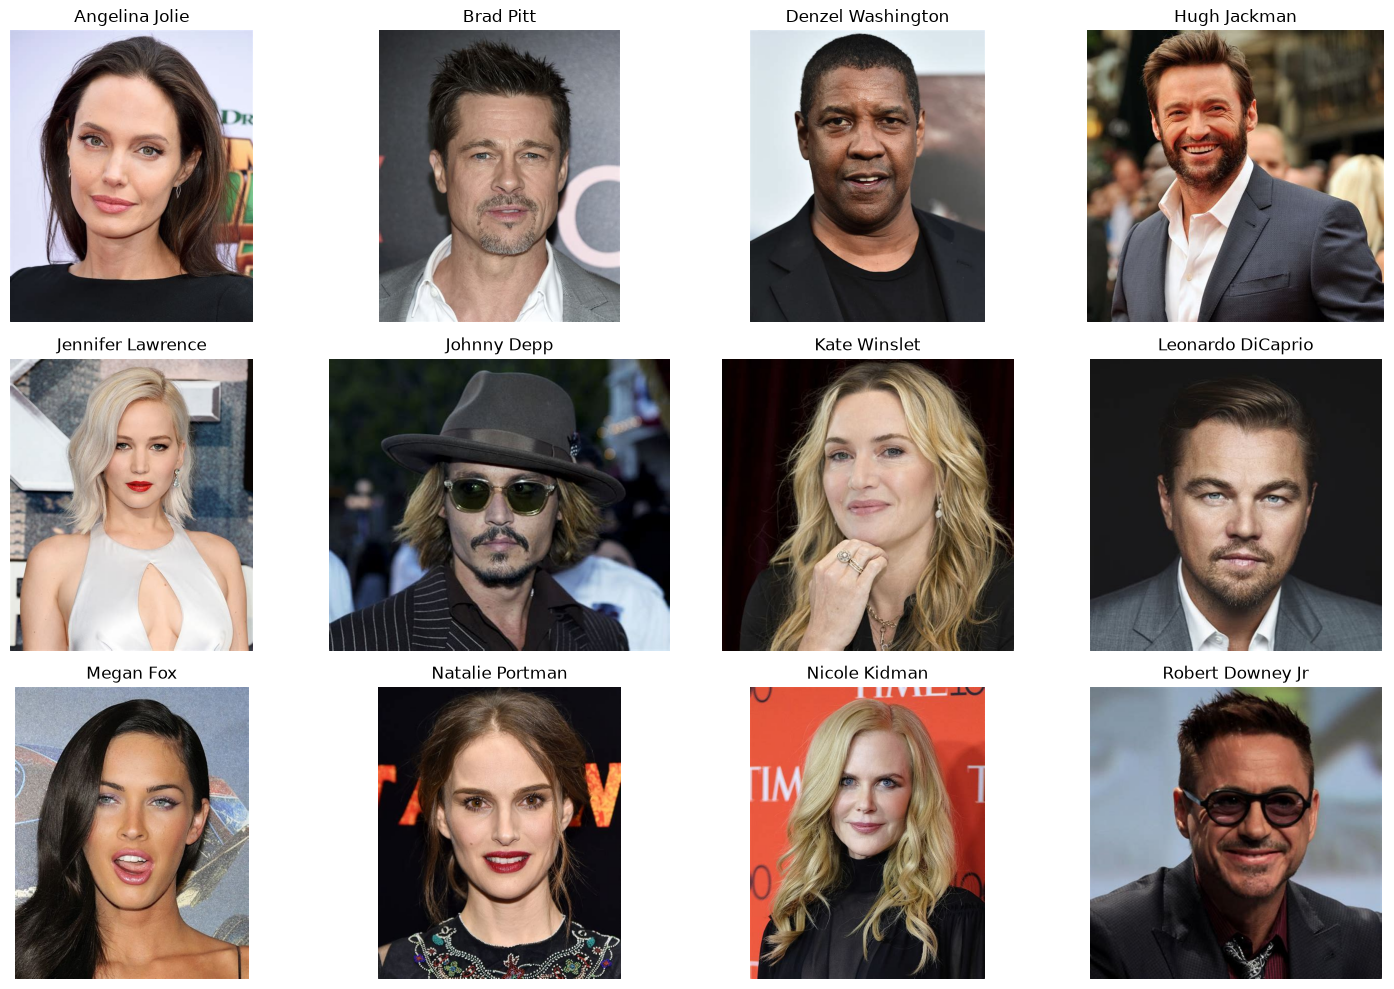

In [12]:
# ============================================================
# CELL 7 - DISPLAY SAMPLE IMAGES
# ============================================================

plt.figure(figsize=(15, 10))

sample_classes = classes[:min(12, len(classes))]

for i, student in enumerate(sample_classes):

    folder = os.path.join(
        RAW_DIR,
        student
    )

    images = [
        file for file in os.listdir(folder)
        if file.lower().endswith(image_extensions)
    ]

    if len(images) == 0:
        continue

    image_path = os.path.join(
        folder,
        images[0]
    )

    image = Image.open(image_path).convert("RGB")

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(student)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
%pip install mtcnn

  Using cached mtcnn-1.0.0-py3-none-any.whl.metadata (5.8 kB)
  Using cached lz4-4.4.5-cp312-cp312-win_amd64.whl.metadata (3.9 kB)
Using cached mtcnn-1.0.0-py3-none-any.whl (1.9 MB)
Using cached lz4-4.4.5-cp312-cp312-win_amd64.whl (99 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
# ============================================================
# CELL 8 - MTCNN FACE DETECTOR
# ============================================================

from mtcnn import MTCNN

detector = MTCNN()

print("MTCNN face detector initialized successfully.")

MTCNN face detector initialized successfully.


Testing student: Angelina Jolie
Images found: 100
Testing image: C:\Users\adity\OneDrive\Desktop\Assignment 4\dataset\raw\Angelina Jolie\001_fe3347c0.jpg
Faces detected: 1


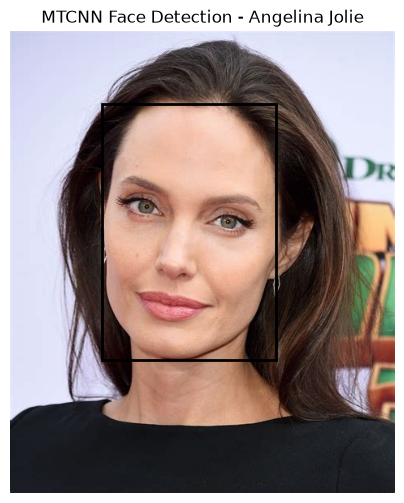

In [14]:
test_student = classes[0]

print("Testing student:", test_student)

test_folder = os.path.join(RAW_DIR, test_student)

test_images = [
    file for file in os.listdir(test_folder)
    if file.lower().endswith(image_extensions)
]

print("Images found:", len(test_images))

test_path = os.path.join(test_folder, test_images[0])

print("Testing image:", test_path)

image = cv2.imread(test_path)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

faces = detector.detect_faces(image_rgb)

print("Faces detected:", len(faces))

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)

ax = plt.gca()

for face in faces:
    x, y, width, height = face["box"]

    x = max(0, x)
    y = max(0, y)

    rectangle = plt.Rectangle(
        (x, y),
        width,
        height,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

plt.axis("off")
plt.title(f"MTCNN Face Detection - {test_student}")
plt.show()

In [15]:
# ============================================================
# CELL 10 - CREATE CROPPED FACE DATASET
# ============================================================

IMG_SIZE = 224

processed_count = 0
failed_count = 0

for student in classes:

    input_folder = os.path.join(
        RAW_DIR,
        student
    )

    output_folder = os.path.join(
        PROCESSED_DIR,
        student
    )

    os.makedirs(
        output_folder,
        exist_ok=True
    )

    files = [
        file
        for file in os.listdir(input_folder)
        if file.lower().endswith(image_extensions)
    ]

    saved = 0

    for file in files:

        input_path = os.path.join(
            input_folder,
            file
        )

        image = cv2.imread(input_path)

        if image is None:
            failed_count += 1
            continue

        image_rgb = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        try:
            faces = detector.detect_faces(image_rgb)
        except Exception:
            failed_count += 1
            continue

        if len(faces) == 0:
            failed_count += 1
            continue

        # Select largest detected face
        face = max(
            faces,
            key=lambda item: item["box"][2] * item["box"][3]
        )

        x, y, width, height = face["box"]

        x = max(0, x)
        y = max(0, y)

        x2 = min(
            image.shape[1],
            x + width
        )

        y2 = min(
            image.shape[0],
            y + height
        )

        face_crop = image_rgb[
            y:y2,
            x:x2
        ]

        if face_crop.size == 0:
            failed_count += 1
            continue

        face_crop = cv2.resize(
            face_crop,
            (IMG_SIZE, IMG_SIZE)
        )

        output_path = os.path.join(
            output_folder,
            os.path.splitext(file)[0] + ".jpg"
        )

        face_crop_bgr = cv2.cvtColor(
            face_crop,
            cv2.COLOR_RGB2BGR
        )

        cv2.imwrite(
            output_path,
            face_crop_bgr
        )

        saved += 1
        processed_count += 1

    print(
        f"{student}: {saved} face images saved"
    )

print("\nTotal processed images:", processed_count)
print("Failed images:", failed_count)

Angelina Jolie: 100 face images saved
Brad Pitt: 100 face images saved
Denzel Washington: 100 face images saved
Hugh Jackman: 100 face images saved
Jennifer Lawrence: 100 face images saved
Johnny Depp: 100 face images saved
Kate Winslet: 99 face images saved
Leonardo DiCaprio: 100 face images saved
Megan Fox: 100 face images saved
Natalie Portman: 100 face images saved
Nicole Kidman: 100 face images saved
Robert Downey Jr: 99 face images saved
Sandra Bullock: 100 face images saved
Scarlett Johansson: 198 face images saved
Tom Cruise: 100 face images saved
Tom Hanks: 98 face images saved
Will Smith: 100 face images saved

Total processed images: 1794
Failed images: 6


In [16]:
# ============================================================
# CELL 11 - CHECK PROCESSED DATASET
# ============================================================

processed_counts = {}

for student in classes:

    folder = os.path.join(
        PROCESSED_DIR,
        student
    )

    if os.path.exists(folder):

        count = sum(
            1
            for file in os.listdir(folder)
            if file.lower().endswith(image_extensions)
        )

    else:
        count = 0

    processed_counts[student] = count

processed_df = pd.DataFrame(
    list(processed_counts.items()),
    columns=["Student", "Processed_Images"]
)

print(processed_df)

print(
    "\nTotal processed images:",
    processed_df["Processed_Images"].sum()
)

               Student  Processed_Images
0       Angelina Jolie               100
1            Brad Pitt               100
2    Denzel Washington               100
3         Hugh Jackman               100
4    Jennifer Lawrence               100
5          Johnny Depp               100
6         Kate Winslet                99
7    Leonardo DiCaprio               100
8            Megan Fox               100
9      Natalie Portman               100
10       Nicole Kidman               100
11    Robert Downey Jr                99
12      Sandra Bullock               100
13  Scarlett Johansson               198
14          Tom Cruise               100
15           Tom Hanks                98
16          Will Smith               100

Total processed images: 1794


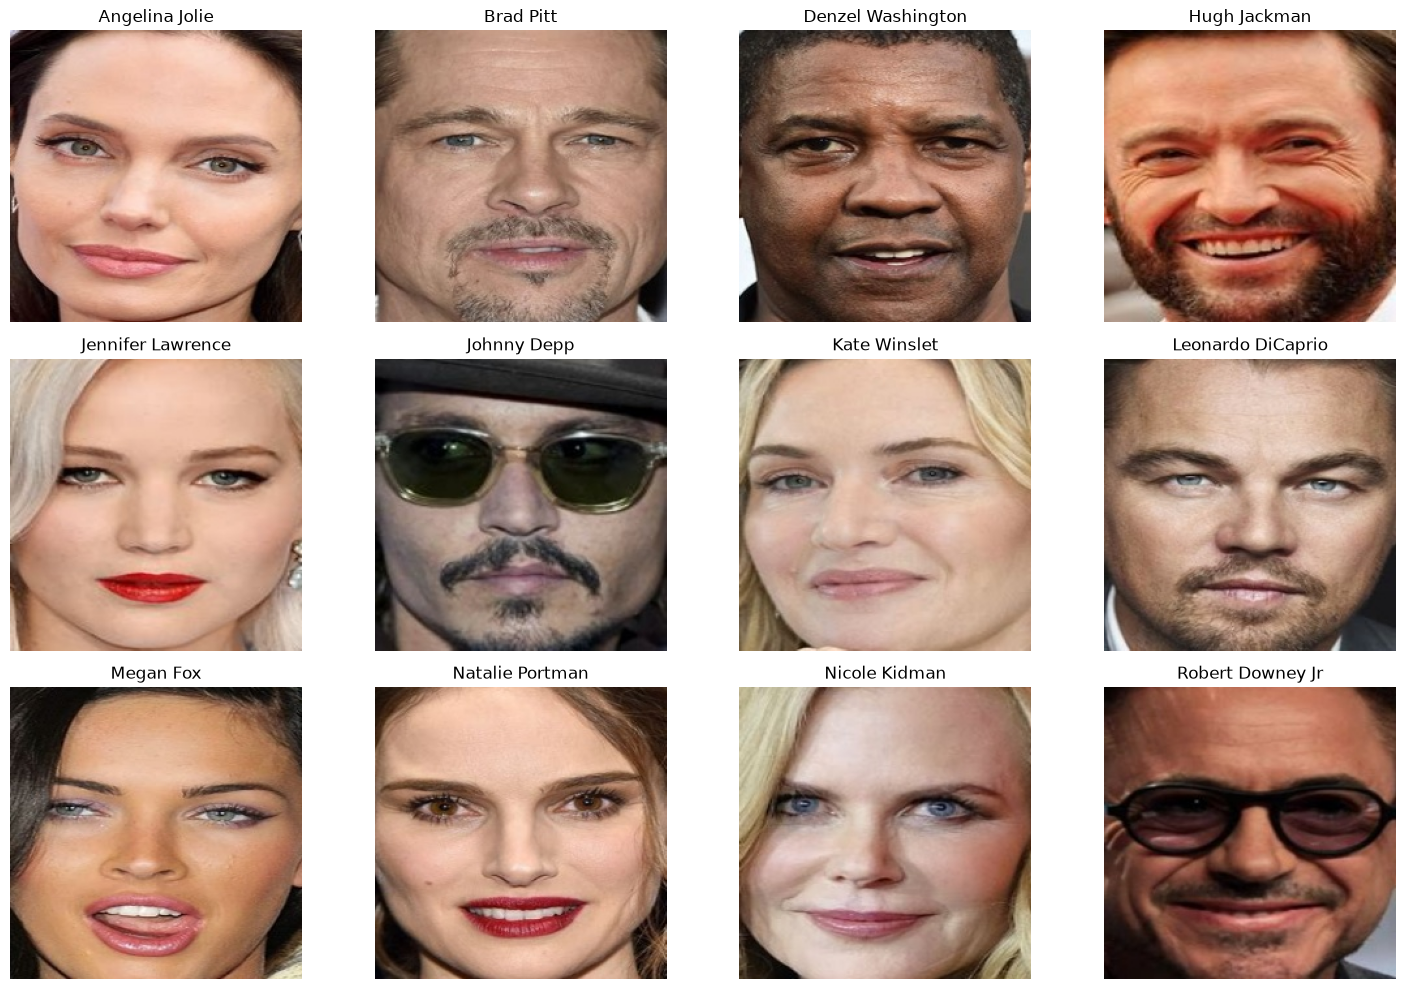

In [17]:
# ============================================================
# CELL 12 - DISPLAY CROPPED FACES
# ============================================================

plt.figure(figsize=(15, 10))

for i, student in enumerate(
    classes[:min(12, len(classes))]
):

    folder = os.path.join(
        PROCESSED_DIR,
        student
    )

    images = [
        file
        for file in os.listdir(folder)
        if file.lower().endswith(image_extensions)
    ]

    if not images:
        continue

    image_path = os.path.join(
        folder,
        images[0]
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    plt.subplot(3, 4, i + 1)
    plt.imshow(image)
    plt.title(student)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# CELL 13 - CREATE DATAFRAME
# ============================================================

data = []

for student in classes:

    folder = os.path.join(
        PROCESSED_DIR,
        student
    )

    if not os.path.exists(folder):
        continue

    for file in os.listdir(folder):

        if file.lower().endswith(image_extensions):

            data.append({
                "filename": os.path.join(
                    folder,
                    file
                ),
                "category": student
            })

df = pd.DataFrame(data)

print("Total images:", len(df))

print("\nClass distribution:")
print(df["category"].value_counts())

Total images: 1794

Class distribution:
category
Scarlett Johansson    198
Angelina Jolie        100
Brad Pitt             100
Denzel Washington     100
Hugh Jackman          100
Jennifer Lawrence     100
Johnny Depp           100
Leonardo DiCaprio     100
Megan Fox             100
Natalie Portman       100
Nicole Kidman         100
Sandra Bullock        100
Tom Cruise            100
Will Smith            100
Kate Winslet           99
Robert Downey Jr       99
Tom Hanks              98
Name: count, dtype: int64


In [19]:
# ============================================================
# CELL 14 - TRAIN / VALIDATION SPLIT
# ============================================================

train_df, validation_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["category"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)

print("Training images:", len(train_df))
print("Validation images:", len(validation_df))

print("\nTraining distribution:")
print(train_df["category"].value_counts())

print("\nValidation distribution:")
print(validation_df["category"].value_counts())

Training images: 1435
Validation images: 359

Training distribution:
category
Scarlett Johansson    158
Will Smith             80
Nicole Kidman          80
Megan Fox              80
Natalie Portman        80
Denzel Washington      80
Angelina Jolie         80
Jennifer Lawrence      80
Brad Pitt              80
Tom Cruise             80
Hugh Jackman           80
Leonardo DiCaprio      80
Johnny Depp            80
Sandra Bullock         80
Tom Hanks              79
Kate Winslet           79
Robert Downey Jr       79
Name: count, dtype: int64

Validation distribution:
category
Scarlett Johansson    40
Robert Downey Jr      20
Natalie Portman       20
Kate Winslet          20
Sandra Bullock        20
Will Smith            20
Brad Pitt             20
Jennifer Lawrence     20
Nicole Kidman         20
Leonardo DiCaprio     20
Angelina Jolie        20
Denzel Washington     20
Megan Fox             20
Tom Cruise            20
Hugh Jackman          20
Johnny Depp           20
Tom Hanks          

In [20]:
# ============================================================
# CELL 15 - DATA AUGMENTATION
# ============================================================

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=10,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    shear_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

validation_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0
)

In [21]:
# ============================================================
# CELL 16 - CREATE IMAGE GENERATORS
# ============================================================

BATCH_SIZE = 16

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filename",
    y_col="category",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

validation_generator = validation_datagen.flow_from_dataframe(
    dataframe=validation_df,
    x_col="filename",
    y_col="category",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

NUM_CLASSES = len(train_generator.class_indices)

print("Number of classes:", NUM_CLASSES)
print("\nClass indices:")
print(train_generator.class_indices)

Found 1435 validated image filenames belonging to 17 classes.
Found 359 validated image filenames belonging to 17 classes.
Number of classes: 17

Class indices:
{'Angelina Jolie': 0, 'Brad Pitt': 1, 'Denzel Washington': 2, 'Hugh Jackman': 3, 'Jennifer Lawrence': 4, 'Johnny Depp': 5, 'Kate Winslet': 6, 'Leonardo DiCaprio': 7, 'Megan Fox': 8, 'Natalie Portman': 9, 'Nicole Kidman': 10, 'Robert Downey Jr': 11, 'Sandra Bullock': 12, 'Scarlett Johansson': 13, 'Tom Cruise': 14, 'Tom Hanks': 15, 'Will Smith': 16}


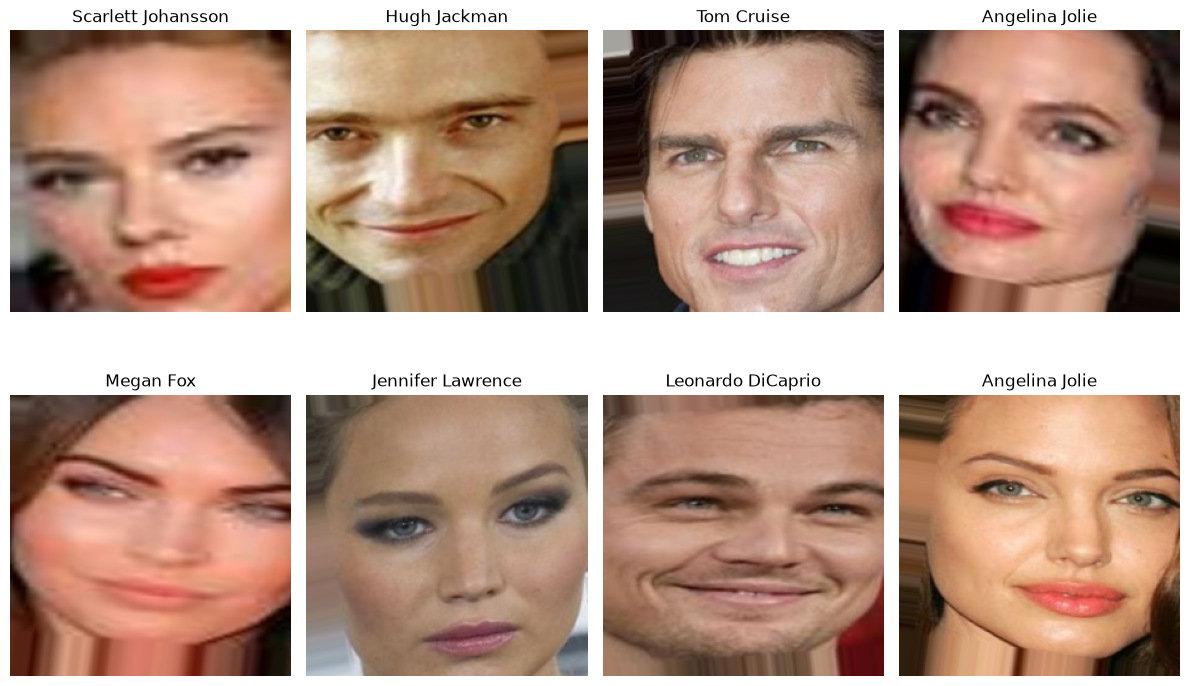

In [22]:
# ============================================================
# CELL 17 - DISPLAY AUGMENTED IMAGES
# ============================================================

images, labels = next(train_generator)

plt.figure(figsize=(12, 8))

for i in range(min(8, len(images))):

    plt.subplot(2, 4, i + 1)

    plt.imshow(images[i])

    class_index = np.argmax(labels[i])

    class_name = list(
        train_generator.class_indices.keys()
    )[class_index]

    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# CELL 18 - CREATE VGG16 CNN MODEL
# ============================================================

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

model = models.Sequential([
    
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        256,
        activation="relu"
    ),

    layers.Dropout(0.5),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,850,385 (56.65 MB)

 Trainable params: 135,697 (530.07 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [24]:
# ============================================================
# CELL 19 - TRAIN CNN MODEL
# ============================================================

EPOCHS = 20

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS
)

Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 101s 1s/step - accuracy: 0.0711 - loss: 2.9326 - val_accuracy: 0.1114 - val_loss: 2.7767
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.0913 - loss: 2.8791 - val_accuracy: 0.1114 - val_loss: 2.7409
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.0997 - loss: 2.8065 - val_accuracy: 0.1114 - val_loss: 2.7105
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.1359 - loss: 2.7458 - val_accuracy: 0.1142 - val_loss: 2.6807
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.1380 - loss: 2.7117 - val_accuracy: 0.1532 - val_loss: 2.6511
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.1568 - loss: 2.6764 - val_accuracy: 0.1671 - val_loss: 2.6172
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.1798 - loss: 2.6346 - val_accuracy: 0.1727 - val_loss: 2.5868
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.1895 - loss: 2.6038 - val_accuracy: 0.2201 - val_lo

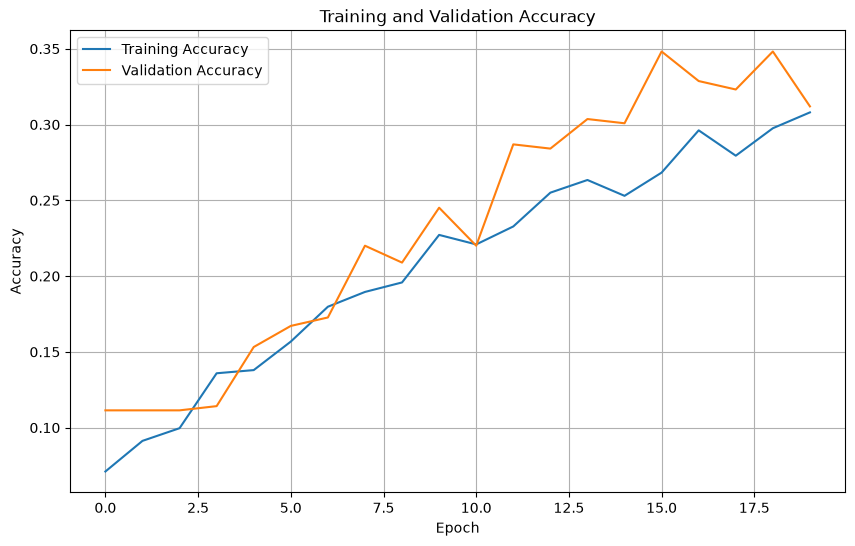

In [25]:
# ============================================================
# CELL 20 - TRAINING AND VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

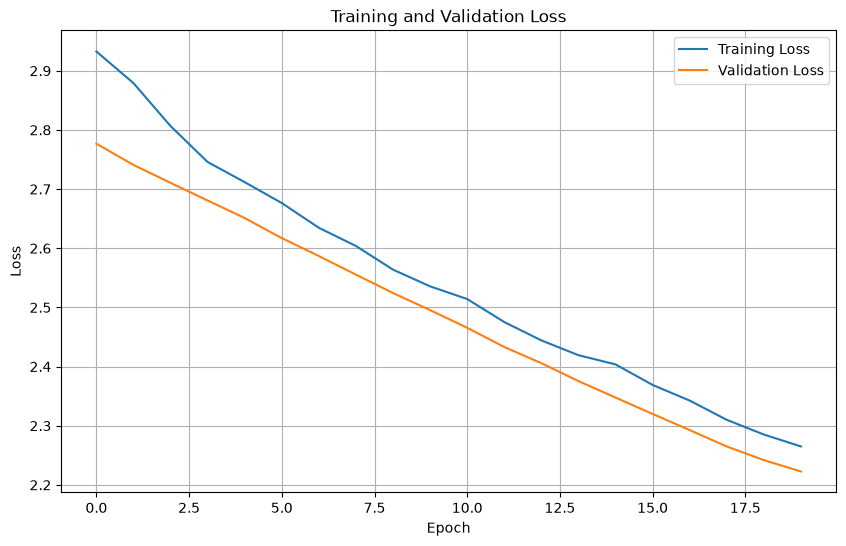

In [26]:
# ============================================================
# CELL 21 - TRAINING AND VALIDATION LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()
plt.grid(True)

plt.show()

In [27]:
# ============================================================
# CELL 22 - MODEL EVALUATION
# ============================================================

validation_loss, validation_accuracy = model.evaluate(
    validation_generator,
    verbose=1
)

print(
    f"\nValidation Loss: {validation_loss:.4f}"
)

print(
    f"Validation Accuracy: "
    f"{validation_accuracy * 100:.2f}%"
)

23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 948ms/step - accuracy: 0.3120 - loss: 2.2227

Validation Loss: 2.2227
Validation Accuracy: 31.20%


In [50]:
# ============================================================
# CELL 23 - SAVE MODEL
# ============================================================

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "face_recognition_vgg16.keras"
)

model.save(MODEL_PATH)

print(
    "Model saved successfully:"
)

print(MODEL_PATH)

Model saved successfully:
D:\Deep Learning\Assignment 4\models\face_recognition_vgg16.keras


In [29]:
# ============================================================
# CELL 24 - PREDICTIONS
# ============================================================

validation_generator.reset()

predictions = model.predict(
    validation_generator,
    verbose=1
)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

true_classes = validation_generator.classes

class_names = list(
    validation_generator.class_indices.keys()
)

print("Number of predictions:", len(predicted_classes))

23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 923ms/step
Number of predictions: 359


In [30]:
# ============================================================
# CELL 25 - CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names,
        zero_division=0
    )
)

                    precision    recall  f1-score   support

    Angelina Jolie       0.38      0.15      0.21        20
         Brad Pitt       1.00      0.05      0.10        20
 Denzel Washington       0.22      0.80      0.34        20
      Hugh Jackman       1.00      0.10      0.18        20
 Jennifer Lawrence       0.00      0.00      0.00        20
       Johnny Depp       0.48      0.55      0.51        20
      Kate Winslet       0.00      0.00      0.00        20
 Leonardo DiCaprio       0.00      0.00      0.00        20
         Megan Fox       0.56      0.45      0.50        20
   Natalie Portman       0.00      0.00      0.00        20
     Nicole Kidman       1.00      0.15      0.26        20
  Robert Downey Jr       0.50      0.20      0.29        20
    Sandra Bullock       0.00      0.00      0.00        20
Scarlett Johansson       0.25      1.00      0.40        40
        Tom Cruise       0.15      0.10      0.12        20
         Tom Hanks       0.50      0.58

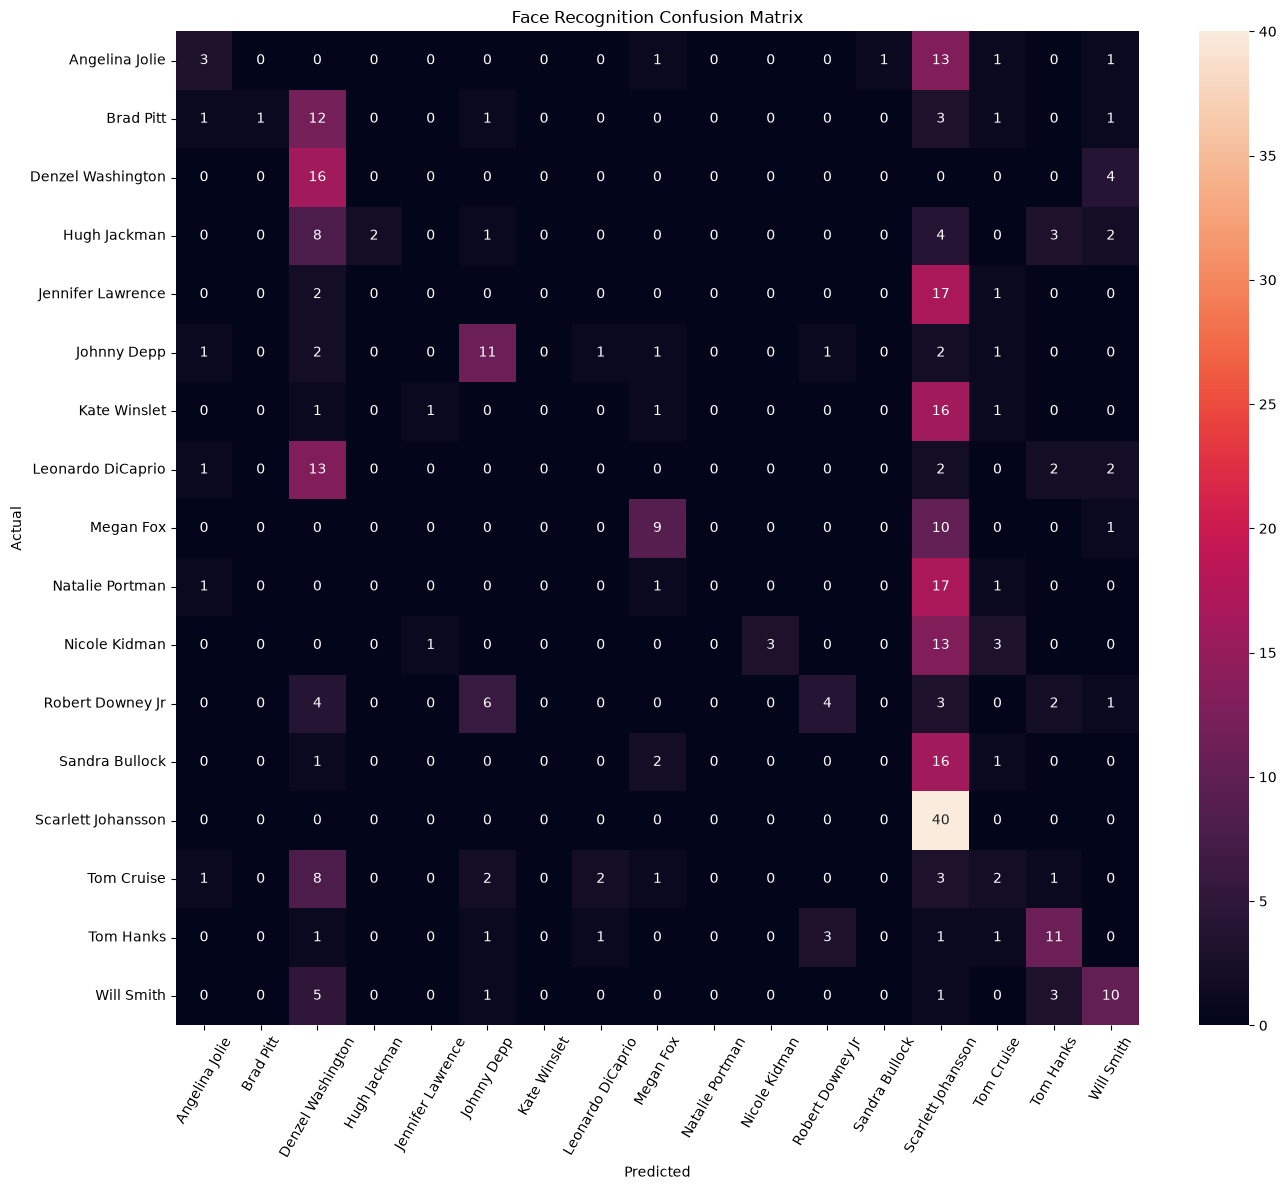

In [31]:
# ============================================================
# CELL 26 - CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    true_classes,
    predicted_classes
)

plt.figure(
    figsize=(14, 12)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "Face Recognition Confusion Matrix"
)

plt.xticks(rotation=60)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# CELL 27 - CREATE DIMENSIONALLY REDUCED DATASETS
# ============================================================

REDUCED_SIZES = [
    112,
    64
]

for size in REDUCED_SIZES:

    size_dir = os.path.join(
        REDUCED_DIR,
        f"{size}x{size}"
    )

    os.makedirs(
        size_dir,
        exist_ok=True
    )

    for student in classes:

        input_folder = os.path.join(
            PROCESSED_DIR,
            student
        )

        output_folder = os.path.join(
            size_dir,
            student
        )

        os.makedirs(
            output_folder,
            exist_ok=True
        )

        if not os.path.exists(input_folder):
            continue

        for file in os.listdir(input_folder):

            if not file.lower().endswith(
                image_extensions
            ):
                continue

            input_path = os.path.join(
                input_folder,
                file
            )

            output_path = os.path.join(
                output_folder,
                file
            )

            image = cv2.imread(input_path)

            if image is None:
                continue

            resized = cv2.resize(
                image,
                (size, size)
            )

            cv2.imwrite(
                output_path,
                resized
            )

    print(
        f"Created {size}x{size} dataset"
    )

Created 112x112 dataset
Created 64x64 dataset


In [33]:
# ============================================================
# CELL 28 - DATAFRAME FUNCTION
# ============================================================

def create_dataframe(dataset_path):

    data = []

    available_classes = sorted([
        folder
        for folder in os.listdir(dataset_path)
        if os.path.isdir(
            os.path.join(dataset_path, folder)
        )
    ])

    for student in available_classes:

        folder = os.path.join(
            dataset_path,
            student
        )

        for file in os.listdir(folder):

            if file.lower().endswith(
                image_extensions
            ):

                data.append({
                    "filename": os.path.join(
                        folder,
                        file
                    ),
                    "category": student
                })

    return pd.DataFrame(data)

In [34]:
# ============================================================
# CELL 29 - REDUCED IMAGE MODEL FUNCTION
# ============================================================

def train_reduced_model(
    image_size,
    epochs=10
):

    dataset_path = os.path.join(
        REDUCED_DIR,
        f"{image_size}x{image_size}"
    )

    data = create_dataframe(
        dataset_path
    )

    train_df_small, val_df_small = train_test_split(
        data,
        test_size=0.20,
        random_state=42,
        stratify=data["category"]
    )

    train_df_small = train_df_small.reset_index(
        drop=True
    )

    val_df_small = val_df_small.reset_index(
        drop=True
    )

    train_datagen_small = ImageDataGenerator(
        rescale=1.0 / 255.0,
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.15,
        horizontal_flip=True
    )

    val_datagen_small = ImageDataGenerator(
        rescale=1.0 / 255.0
    )

    train_gen_small = train_datagen_small.flow_from_dataframe(
        train_df_small,
        x_col="filename",
        y_col="category",
        target_size=(image_size, image_size),
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=True,
        seed=42
    )

    val_gen_small = val_datagen_small.flow_from_dataframe(
        val_df_small,
        x_col="filename",
        y_col="category",
        target_size=(image_size, image_size),
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )

    num_classes_small = len(
        train_gen_small.class_indices
    )

    base_small = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(
            image_size,
            image_size,
            3
        )
    )

    base_small.trainable = False

    model_small = models.Sequential([
        
        base_small,

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            256,
            activation="relu"
        ),

        layers.Dropout(0.5),

        layers.Dense(
            num_classes_small,
            activation="softmax"
        )
    ])

    model_small.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0001
        ),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history_small = model_small.fit(
        train_gen_small,
        validation_data=val_gen_small,
        epochs=epochs,
        verbose=1
    )

    loss, accuracy = model_small.evaluate(
        val_gen_small,
        verbose=0
    )

    return (
        model_small,
        history_small,
        accuracy
    )

In [35]:
# ============================================================
# CELL 30 - TRAIN 112x112 MODEL
# ============================================================

model_112, history_112, accuracy_112 = train_reduced_model(
    image_size=112,
    epochs=10
)

print(
    f"112x112 Validation Accuracy: "
    f"{accuracy_112 * 100:.2f}%"
)

Found 1435 validated image filenames belonging to 17 classes.
Found 359 validated image filenames belonging to 17 classes.
Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 37s 403ms/step - accuracy: 0.0767 - loss: 2.9154 - val_accuracy: 0.1504 - val_loss: 2.7357
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 29s 325ms/step - accuracy: 0.1129 - loss: 2.7928 - val_accuracy: 0.1560 - val_loss: 2.6676
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 30s 334ms/step - accuracy: 0.1443 - loss: 2.7162 - val_accuracy: 0.1755 - val_loss: 2.6063
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 30s 334ms/step - accuracy: 0.1638 - loss: 2.6297 - val_accuracy: 0.2061 - val_loss: 2.5502
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 30s 336ms/step - accuracy: 0.2146 - loss: 2.5553 - val_accuracy: 0.2228 - val_loss: 2.4953
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 30s 329ms/step - accuracy: 0.2042 - loss: 2.5028 - val_accuracy: 0.2507 - val_loss: 2.4389
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 29s 326ms/step - accuracy: 0.2328 - loss: 2.4486 - val_accuracy: 

In [36]:
# ============================================================
# CELL 31 - TRAIN 64x64 MODEL
# ============================================================

model_64, history_64, accuracy_64 = train_reduced_model(
    image_size=64,
    epochs=10
)

print(
    f"64x64 Validation Accuracy: "
    f"{accuracy_64 * 100:.2f}%"
)

Found 1435 validated image filenames belonging to 17 classes.
Found 359 validated image filenames belonging to 17 classes.
Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 23s 248ms/step - accuracy: 0.0683 - loss: 3.0319 - val_accuracy: 0.1142 - val_loss: 2.7626
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.1010 - loss: 2.8416 - val_accuracy: 0.1588 - val_loss: 2.6746
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.1331 - loss: 2.7285 - val_accuracy: 0.2145 - val_loss: 2.6029
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.1463 - loss: 2.6330 - val_accuracy: 0.2368 - val_loss: 2.5350
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.1986 - loss: 2.5280 - val_accuracy: 0.2786 - val_loss: 2.4523
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.2439 - loss: 2.4656 - val_accuracy: 0.2897 - val_loss: 2.3880
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.2585 - loss: 2.3844 - val_accuracy: 

In [37]:
# ============================================================
# CELL 32 - DIMENSIONALITY REDUCTION ACCURACY COMPARISON
# ============================================================

accuracy_results = pd.DataFrame({
    "Image Size": [
        "224x224",
        "112x112",
        "64x64"
    ],

    "Accuracy": [
        validation_accuracy,
        accuracy_112,
        accuracy_64
    ]
})

accuracy_results["Accuracy (%)"] = (
    accuracy_results["Accuracy"] * 100
)

print(accuracy_results)

  Image Size  Accuracy  Accuracy (%)
0    224x224  0.311978     31.197771
1    112x112  0.384401     38.440111
2      64x64  0.317549     31.754875


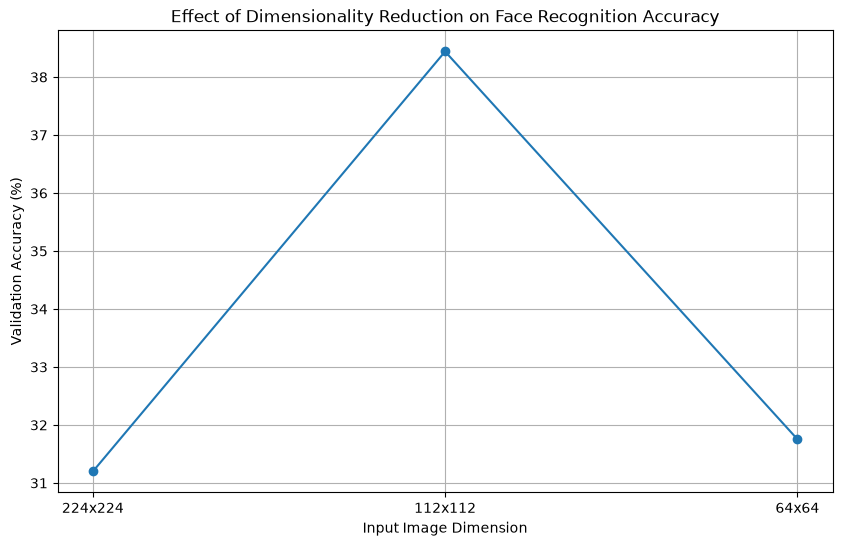

In [38]:
# ============================================================
# CELL 33 - PLOT ACCURACY VS IMAGE DIMENSION
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    accuracy_results["Image Size"],
    accuracy_results["Accuracy (%)"],
    marker="o"
)

plt.xlabel(
    "Input Image Dimension"
)

plt.ylabel(
    "Validation Accuracy (%)"
)

plt.title(
    "Effect of Dimensionality Reduction on "
    "Face Recognition Accuracy"
)

plt.grid(True)

plt.show()

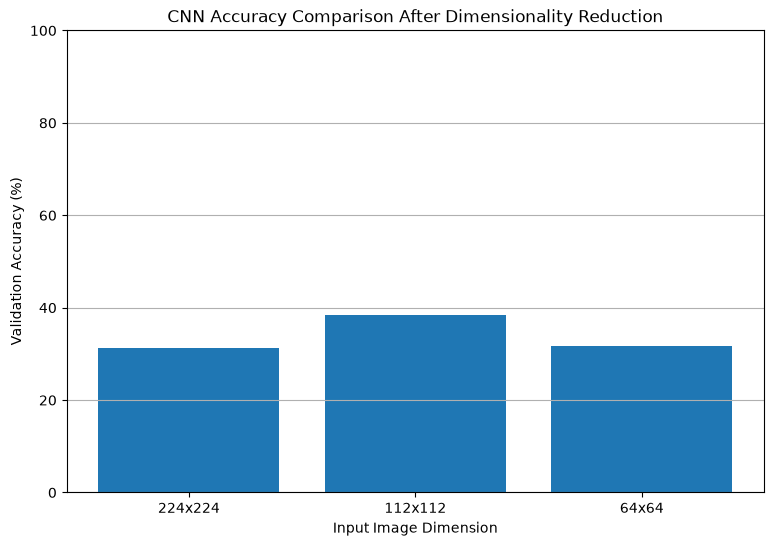

In [39]:
# ============================================================
# CELL 34 - BAR CHART COMPARISON
# ============================================================

plt.figure(figsize=(9, 6))

plt.bar(
    accuracy_results["Image Size"],
    accuracy_results["Accuracy (%)"]
)

plt.xlabel(
    "Input Image Dimension"
)

plt.ylabel(
    "Validation Accuracy (%)"
)

plt.title(
    "CNN Accuracy Comparison After "
    "Dimensionality Reduction"
)

plt.ylim(
    0,
    100
)

plt.grid(
    axis="y"
)

plt.show()

In [40]:
# ============================================================
# CELL 35 - CALCULATE INPUT DIMENSION REDUCTION
# ============================================================

dimensions = {
    "224x224": 224 * 224 * 3,
    "112x112": 112 * 112 * 3,
    "64x64": 64 * 64 * 3
}

for name, values in dimensions.items():

    print(
        f"{name}: {values:,} input values"
    )

224x224: 150,528 input values
112x112: 37,632 input values
64x64: 12,288 input values


In [41]:
# ============================================================
# CELL 36 - REDUCTION PERCENTAGE
# ============================================================

original_dimension = dimensions["224x224"]

for name, value in dimensions.items():

    reduction = (
        1 - value / original_dimension
    ) * 100

    print(
        f"{name}: "
        f"{reduction:.2f}% reduction"
    )

224x224: 0.00% reduction
112x112: 75.00% reduction
64x64: 91.84% reduction


In [42]:
# ============================================================
# CELL 37 - SINGLE IMAGE PREDICTION
# ============================================================

def predict_face(
    image_path,
    model,
    class_names,
    image_size=224
):

    image = cv2.imread(image_path)

    if image is None:
        print("Could not read image.")
        return

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    faces = detector.detect_faces(
        image_rgb
    )

    if len(faces) == 0:

        print(
            "No face detected."
        )

        plt.imshow(image_rgb)
        plt.axis("off")
        plt.show()

        return

    face = max(
        faces,
        key=lambda item:
        item["box"][2] * item["box"][3]
    )

    x, y, width, height = face["box"]

    x = max(0, x)
    y = max(0, y)

    x2 = min(
        image_rgb.shape[1],
        x + width
    )

    y2 = min(
        image_rgb.shape[0],
        y + height
    )

    face_crop = image_rgb[
        y:y2,
        x:x2
    ]

    face_crop = cv2.resize(
        face_crop,
        (image_size, image_size)
    )

    input_image = (
        face_crop.astype(
            np.float32
        ) / 255.0
    )

    input_image = np.expand_dims(
        input_image,
        axis=0
    )

    prediction = model.predict(
        input_image,
        verbose=0
    )[0]

    predicted_index = np.argmax(
        prediction
    )

    predicted_name = class_names[
        predicted_index
    ]

    confidence = prediction[
        predicted_index
    ] * 100

    plt.figure(figsize=(6, 6))

    plt.imshow(face_crop)

    plt.title(
        f"Prediction: {predicted_name}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.axis("off")
    plt.show()

    return predicted_name, confidence

Testing student: Angelina Jolie
Images found: 100
Testing image: C:\Users\adity\OneDrive\Desktop\Assignment 4\dataset\raw\Angelina Jolie\001_fe3347c0.jpg
Faces detected: 1


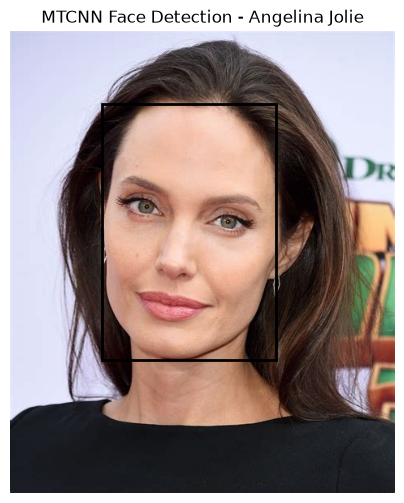

In [43]:
test_student = classes[0]

print("Testing student:", test_student)

test_folder = os.path.join(RAW_DIR, test_student)

test_images = [
    file for file in os.listdir(test_folder)
    if file.lower().endswith(image_extensions)
]

print("Images found:", len(test_images))

test_path = os.path.join(test_folder, test_images[0])

print("Testing image:", test_path)

image = cv2.imread(test_path)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

faces = detector.detect_faces(image_rgb)

print("Faces detected:", len(faces))

plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)

ax = plt.gca()

for face in faces:
    x, y, width, height = face["box"]

    x = max(0, x)
    y = max(0, y)

    rectangle = plt.Rectangle(
        (x, y),
        width,
        height,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

plt.axis("off")
plt.title(f"MTCNN Face Detection - {test_student}")
plt.show()

In [ ]:
# ============================================================
# CELL 38 - TEST SINGLE IMAGE
# ============================================================

test_image_path = (
    r"D:\Deep Learning\Face_Recognition_CNN"
    r"\dataset\raw\Angelina Jolie\093_6ce62543.jpg"
)

predict_face(
    test_image_path,
    model,
    class_names,
    image_size=224
)

Could not read image.


In [48]:
# ============================================================
# CELL 39 - SAVE RESULTS
# ============================================================

RESULT_FILE = os.path.join(
    RESULT_DIR,
    "accuracy_comparison.csv"
)

accuracy_results.to_csv(
    RESULT_FILE,
    index=False
)

print(
    "Results saved to:"
)

print(RESULT_FILE)

Results saved to:
D:\Deep Learning\Assignment 4\results\accuracy_comparison.csv


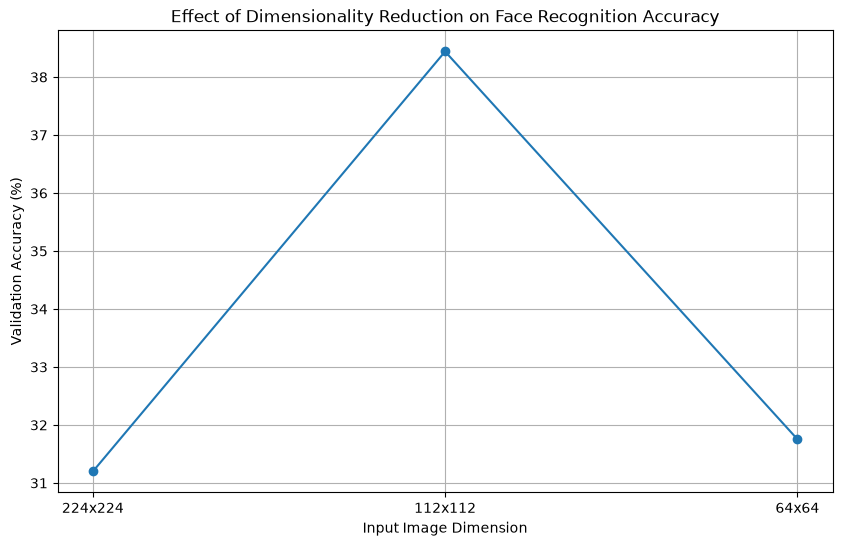

Plot saved to:
D:\Deep Learning\Assignment 4\results\dimensionality_reduction_accuracy.png


In [49]:
# ============================================================
# CELL 40 - SAVE ACCURACY PLOT
# ============================================================

PLOT_FILE = os.path.join(
    RESULT_DIR,
    "dimensionality_reduction_accuracy.png"
)

plt.figure(figsize=(10, 6))

plt.plot(
    accuracy_results["Image Size"],
    accuracy_results["Accuracy (%)"],
    marker="o"
)

plt.xlabel(
    "Input Image Dimension"
)

plt.ylabel(
    "Validation Accuracy (%)"
)

plt.title(
    "Effect of Dimensionality Reduction "
    "on Face Recognition Accuracy"
)

plt.grid(True)

plt.savefig(
    PLOT_FILE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Plot saved to:"
)

print(PLOT_FILE)